# For analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import folium
import geopandas as gpd
from scipy import stats



In [2]:
# Read the data (adjust the file path)
df = pd.read_csv('property_details_updated.csv', dtype=str)  # read everything as string first

# Replace 'N/A' with proper missing value
df = df.replace('N/A', pd.NA)

# Columns to exclude from integer conversion
exclude_cols = ['Link', 'Date_scraped']

# For all other columns, attempt conversion to nullable integer
for col in df.columns:
    if col in exclude_cols:
        continue

    # First, try to convert to float (handles numbers with decimals)
    # This will also turn pandas.NA into float NaN, but we'll later convert to Int64
    try:
        df[col] = pd.to_numeric(df[col], errors='coerce')  # coerce invalid to NaN
    except Exception:
        # If conversion fails completely, leave as is (or you may choose to drop)
        print(f"Column '{col}' could not be converted to numeric.")
        continue

    # Now convert to nullable integer (Int64). This will keep NaN as <NA>
    # If you want to round decimals first, do: df[col] = df[col].round().astype('Int64')
    # Here we simply convert – if there are decimals, this will raise an error!
    # To avoid errors, we round to nearest integer:
    df[col] = df[col].round().astype('Int64')

# Check the result
print(df.dtypes)
print(df.head())

Link                                   object
Locality                                Int64
Type of property                        Int64
Subtype of property                     Int64
Price                                   Int64
Type of sale                            Int64
Number of rooms                         Int64
Livable surface                         Int64
Fully equipped kitchen                  Int64
Furnished                               Int64
Fireplace                               Int64
Terrace                                 Int64
Surface terrace                         Int64
Garden                                  Int64
Garden area                             Int64
Total land surface                      Int64
Number of facades                       Int64
Swimming pool                           Int64
State of the property                   Int64
Specific primary energy consumption     Int64
Garage                                  Int64
Date_scraped                      

In [3]:
df.to_csv('property_details_Update.csv', index=False)
print(f"Final cleaned data saved to 'property_details_Update.csv' ({len(df)} rows)")

Final cleaned data saved to 'property_details_Update.csv' (30337 rows)


In [4]:

# --- Map Type of sale to transaction type ---
def map_transaction_type(val):
    if val == 1:
        return 'rent'
    elif val == 2:
        return 'sale'
    else:
        return np.nan

if 'Type of sale' in df.columns:
    df['transaction_type'] = df['Type of sale'].apply(map_transaction_type)
else:
    raise KeyError("Column 'Type of sale' not found in the data.")

# --- Compute missing price_per_m2 where possible ---
df['price_per_m2'] = pd.to_numeric(df['price_per_m2'], errors='coerce')
df['Livable surface'] = pd.to_numeric(df['Livable surface'], errors='coerce')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

mask = df['price_per_m2'].isna() & df['Price'].notna() & df['Livable surface'].notna() & (df['Livable surface'] > 0)
df.loc[mask, 'price_per_m2'] = df.loc[mask, 'Price'] / df.loc[mask, 'Livable surface']

# --- Drop rows without valid price_per_m2 or transaction type ---
df_clean = df.dropna(subset=['price_per_m2', 'transaction_type']).copy()

# --- Group zip codes by first digit (e.g., 1000–1999 → 1000) ---
df_clean['zip_region'] = (df_clean['Locality'] // 1000) * 1000

# --- Aggregate: mean price per m² per region and transaction type ---
grouped = df_clean.groupby(['zip_region', 'transaction_type'])['price_per_m2'].mean().reset_index()

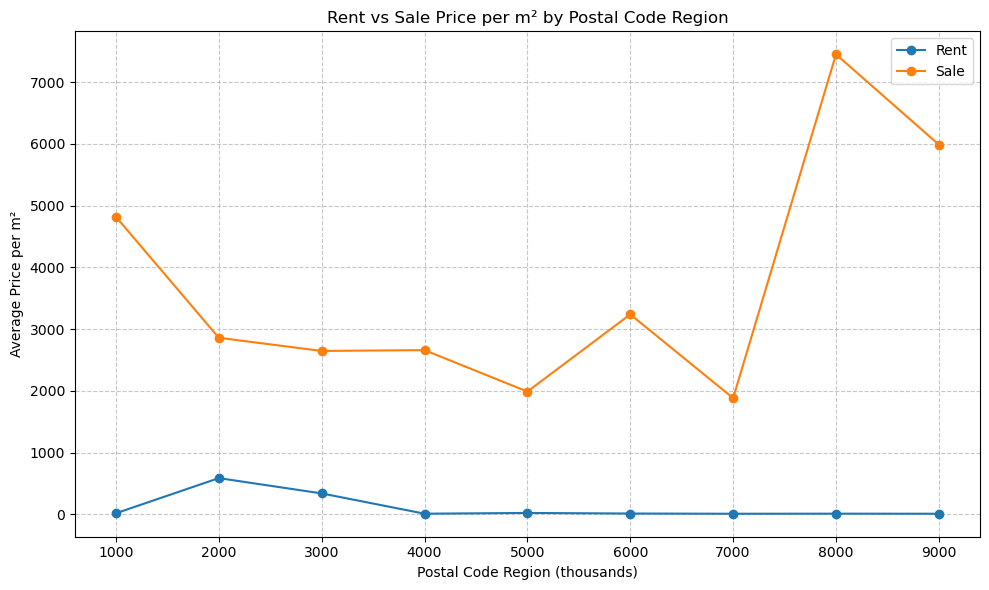

In [5]:
# --- Pivot for plotting ---
pivot = grouped.pivot(index='zip_region', columns='transaction_type', values='price_per_m2').fillna(0)

# --- Plot ---
plt.figure(figsize=(10, 6))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], marker='o', label=col.capitalize())

plt.xlabel('Postal Code Region (thousands)')
plt.ylabel('Average Price per m²')
plt.title('Rent vs Sale Price per m² by Postal Code Region')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(sorted(pivot.index))
plt.tight_layout()
plt.show()

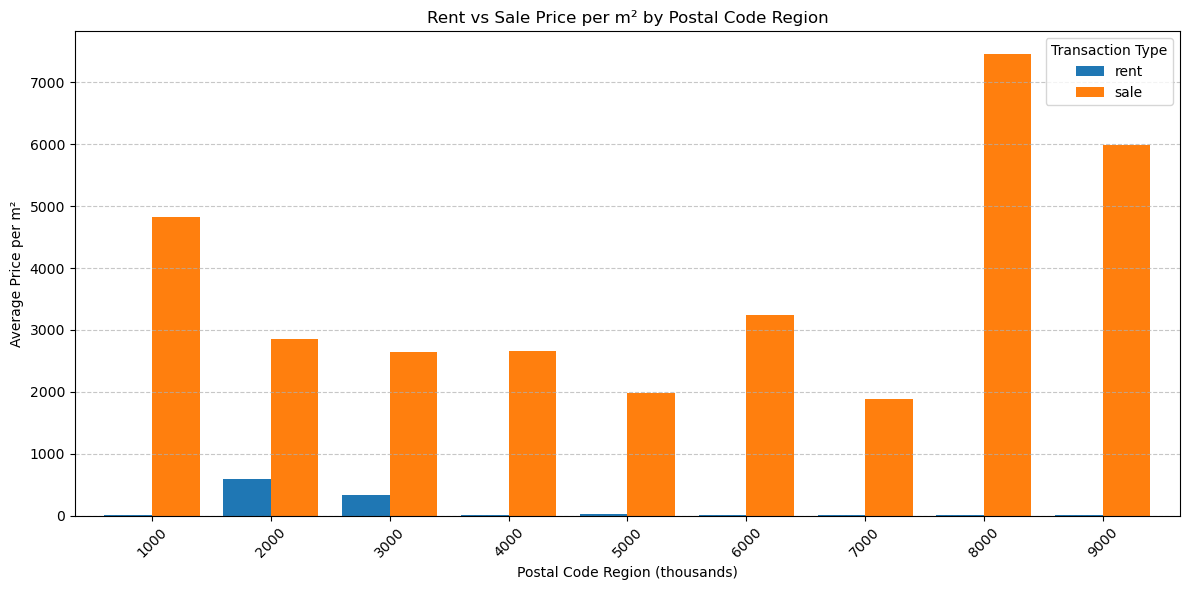

In [6]:
# --- Aggregate: mean price per m² per region and transaction type ---
grouped = df_clean.groupby(['zip_region', 'transaction_type'])['price_per_m2'].mean().reset_index()

# --- Pivot for plotting ---
pivot = grouped.pivot(index='zip_region', columns='transaction_type', values='price_per_m2').fillna(0)

# --- Plot grouped bar chart ---
ax = pivot.plot(kind='bar', figsize=(12, 6), width=0.8)
plt.xlabel('Postal Code Region (thousands)')
plt.ylabel('Average Price per m²')
plt.title('Rent vs Sale Price per m² by Postal Code Region')
plt.legend(title='Transaction Type')
plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.xticks(rotation=45)  # Rotate labels for better readability
plt.tight_layout()
plt.show()

In [7]:
# plt.figure(figsize=(12,14))

# plt.subplot(2,1,1)

# group_full = df.groupby('Livable surface')['price'].mean()
# group = group_full.reset_index()

# x = group['house_area']
# y = group['price']
# plt.title("Moyenne de prix par la surface du batiment")
# plt.xlabel('House Area (m²)')
# plt.ylabel('Price (€)');
# plt.scatter(x, y)


# plt.subplot(2,1,2)

# group_full = df.groupby('house_area')['price'].mean()
# group = group_full.reset_index()
# group = group[group['house_area'] > 0]
# group = group[group['house_area'] < 500]

# print(group)

# x = group['house_area']
# y = group['price']
# plt.title("Moyenne de prix par la surface du batiment")
# plt.xlabel('House Area (m²)')
# plt.ylabel('Price (€)');

# # calc the trendline 
# z = np.polyfit(x, y, 1) 
# p = np.poly1d(z) 

# # the line equation: 
# print ("y=%.6fx+(%.6f)"%(z[0],z[1]) )

# plt.scatter(x, y)
# # plt.plot(group)
# plt.plot(x,p(x),"r--", lw="5")

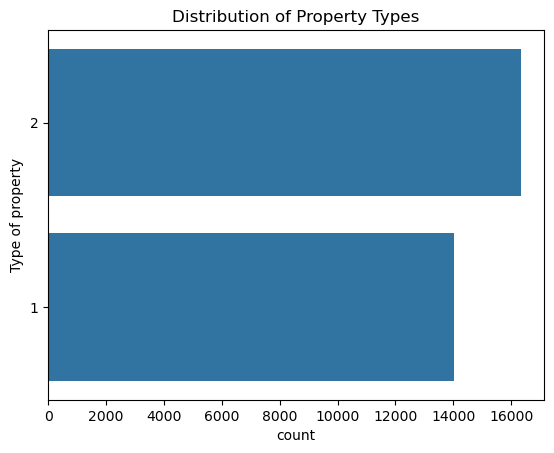

In [8]:
# Focusing on 'Type of property'
sns.countplot(data=df, y='Type of property', order=df['Type of property'].value_counts().index)
plt.title('Distribution of Property Types')
plt.show()

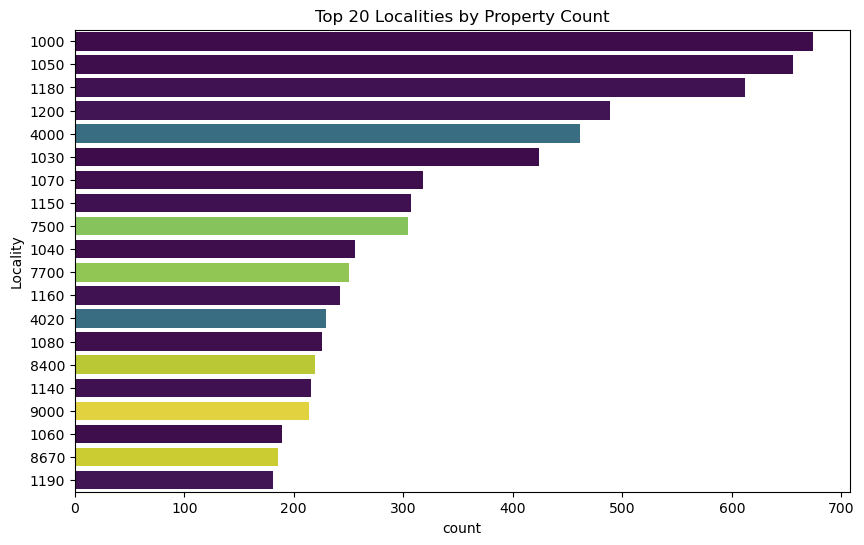

In [9]:
# Get top 9 localities by property count (from cleaned data)
top_localities = df_clean['Locality'].value_counts().head(20).index

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_clean[df_clean['Locality'].isin(top_localities)],
    y='Locality',
    order=top_localities,
    hue='Locality',
    legend=False,
    palette='viridis'
)
plt.title('Top 20 Localities by Property Count')
plt.show()

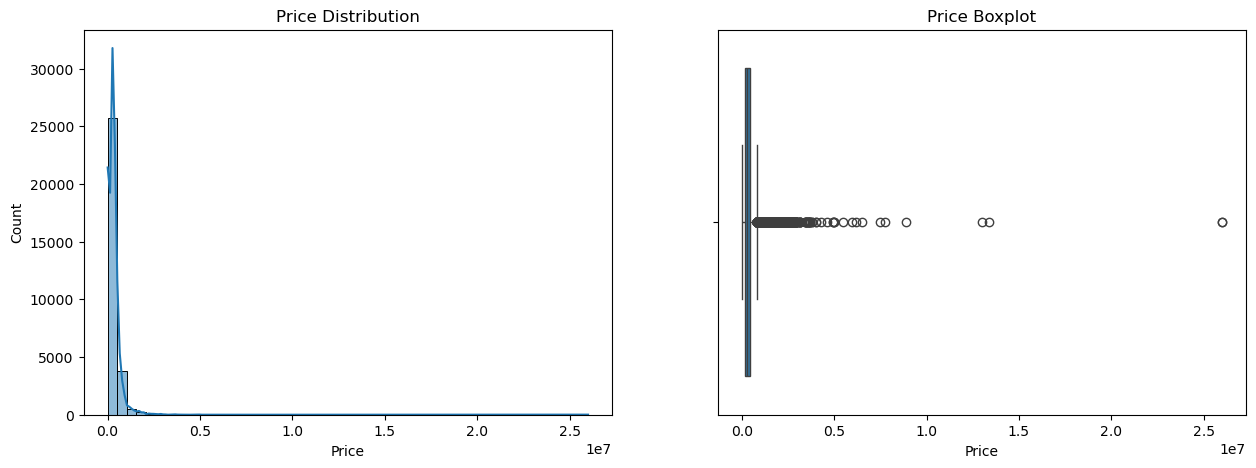

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
sns.histplot(df['Price'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Price Distribution')

# Boxplot to see outliers
sns.boxplot(x=df['Price'], ax=axes[1])
axes[1].set_title('Price Boxplot')
plt.show()

In [11]:
# # Checking the correlation
# categorical_cols = [
#     'Locality', 'Type of property', 'Subtype of property', 
#     'Type of sale', 'State of the property'
# ]

# # Convert strings to numeric codes
# # using .astype('category').cat.codes to assign an integer to each string
# df_numeric = df.copy()
# for col in categorical_cols:
#     df_numeric[col] = df_numeric[col].astype('category').cat.codes

# # Calculate the correlation matrix
# corr_matrix = df_numeric.corr()

# #Plot using Seaborn and Matplotlib
# plt.figure(figsize=(14, 10))
# sns.heatmap(
#     corr_matrix, 
#     annot=True,          # Show the correlation numbers
#     fmt=".2f",           # Limit to 2 decimal places
#     cmap='coolwarm',     # Red for positive, Blue for negative correlation
#     linewidths=0.5,      # Add lines between squares
#     center=0             # Set the color neutral point at 0
# )
# plt.title('Property Attribute Correlation Matrix')
# plt.show()

Generating Pairplot for SALE...


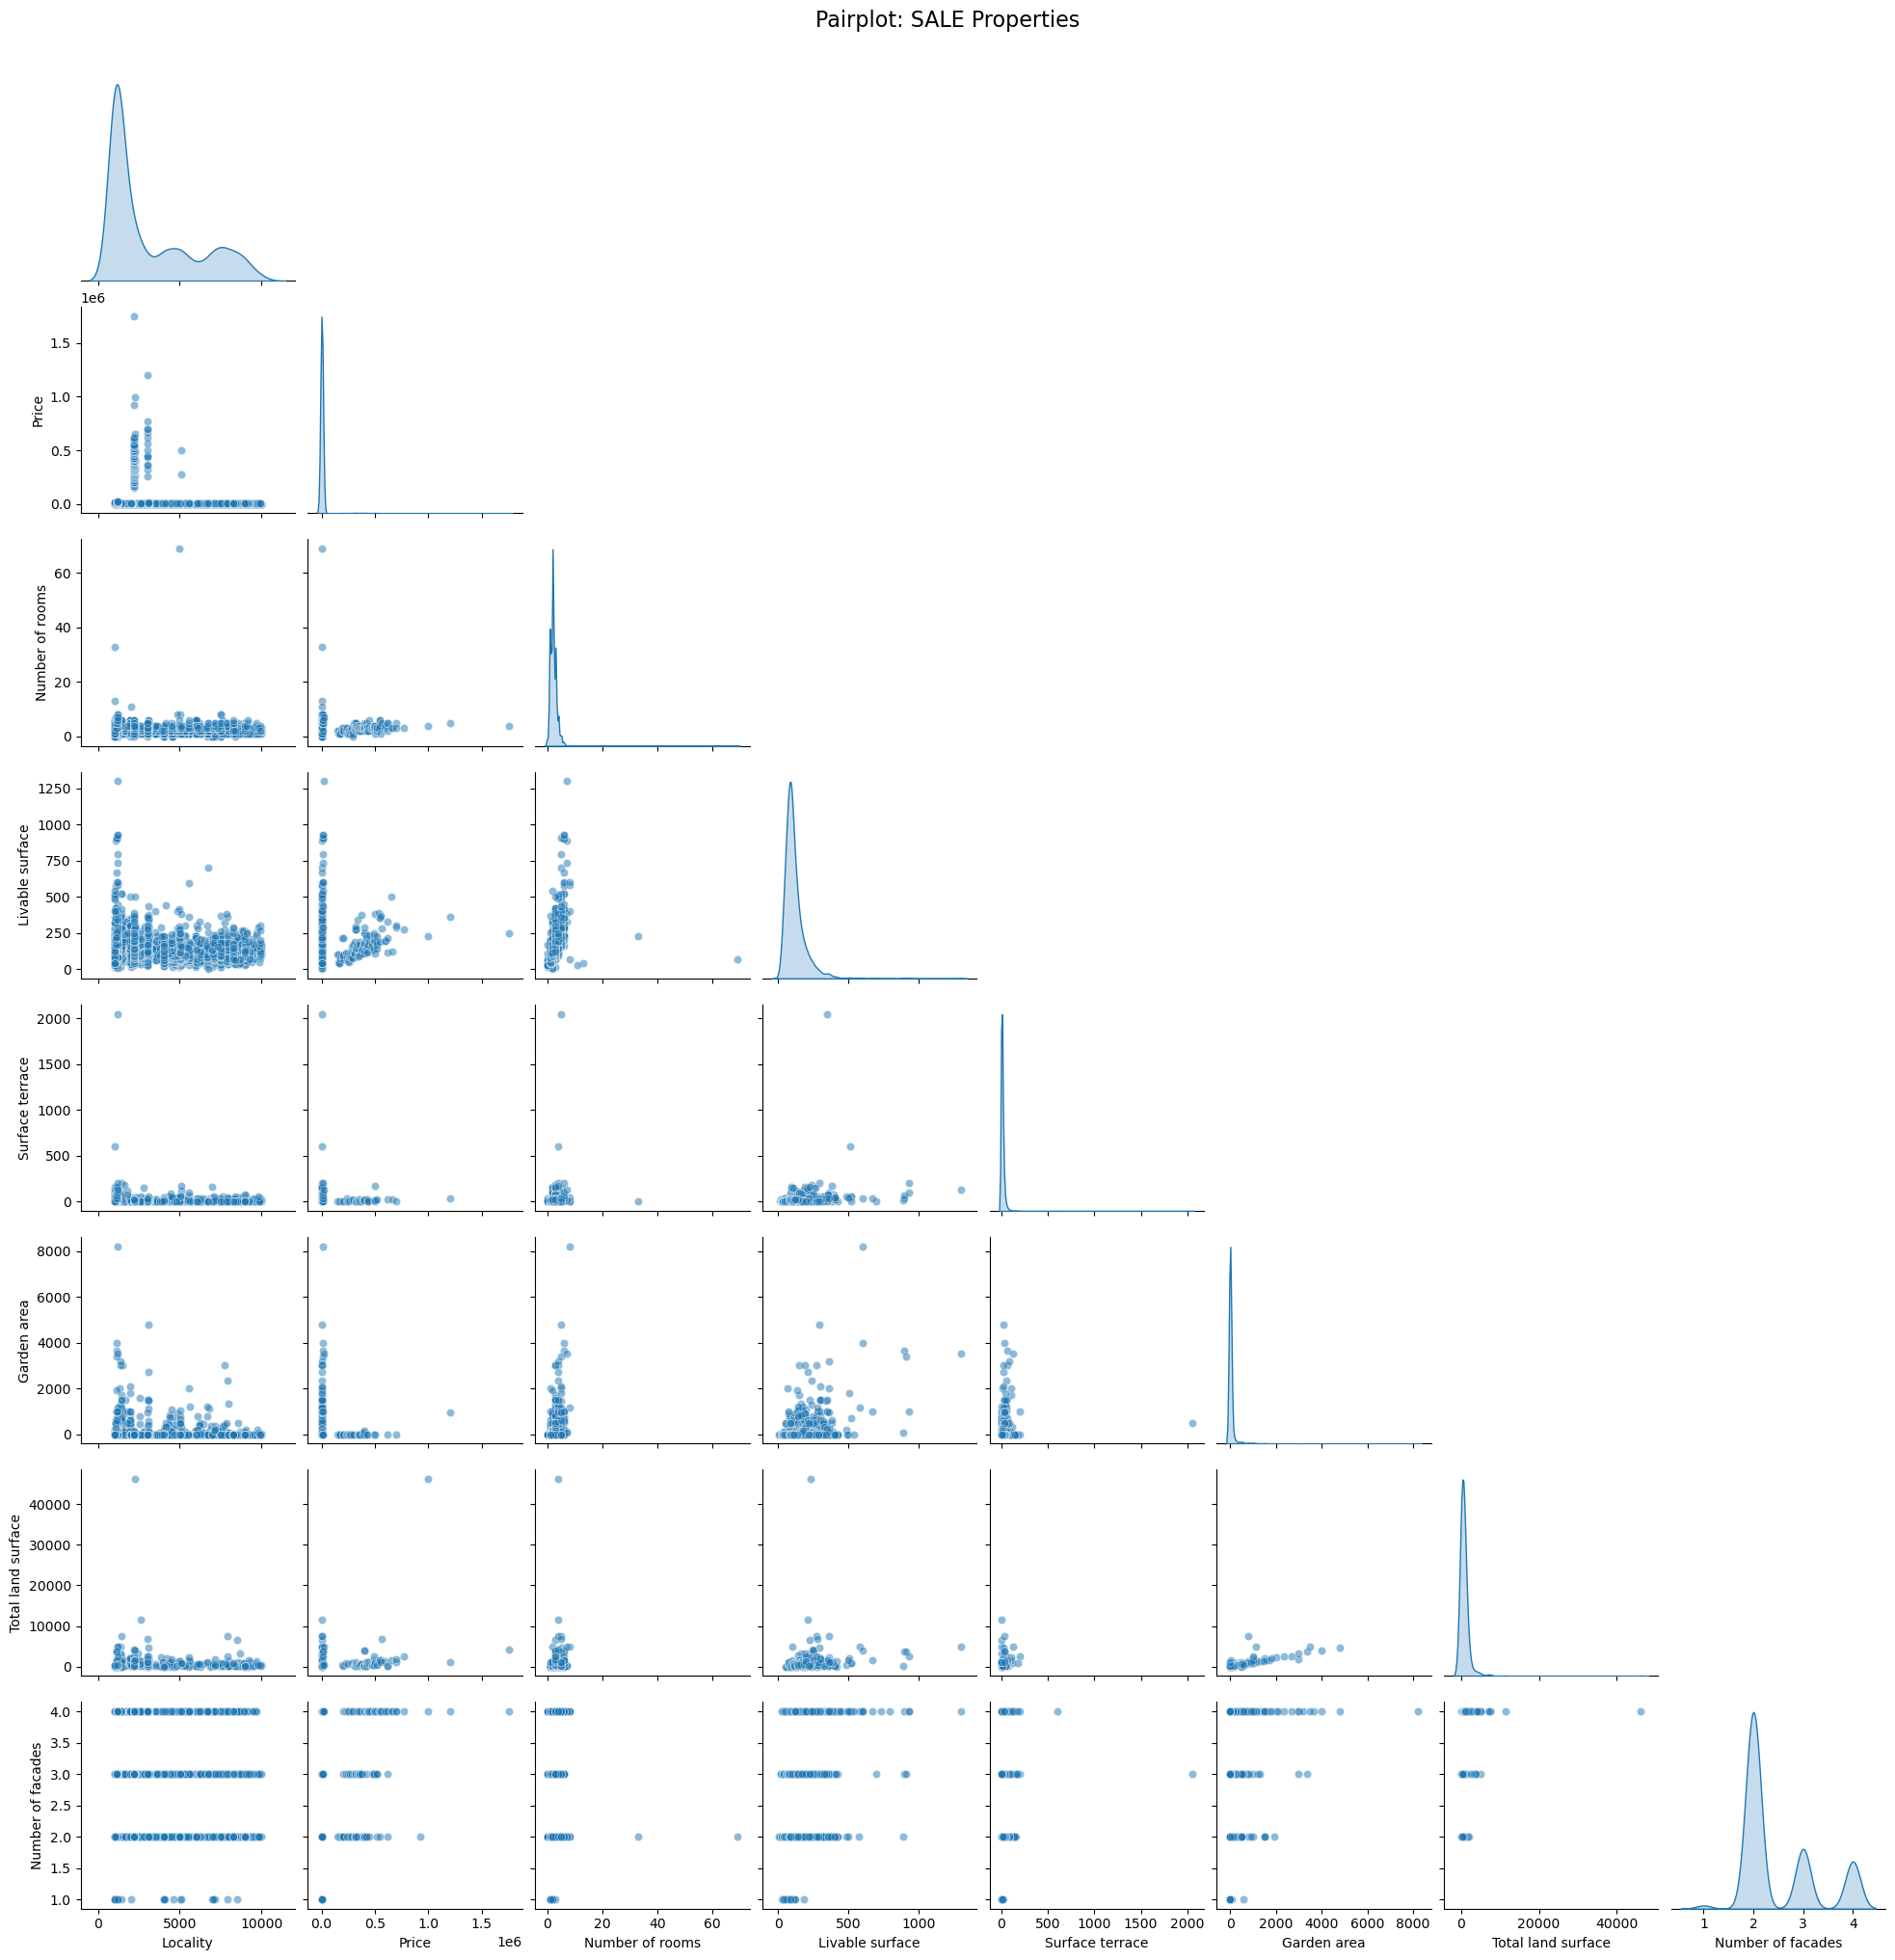

Generating Pairplot for RENT...


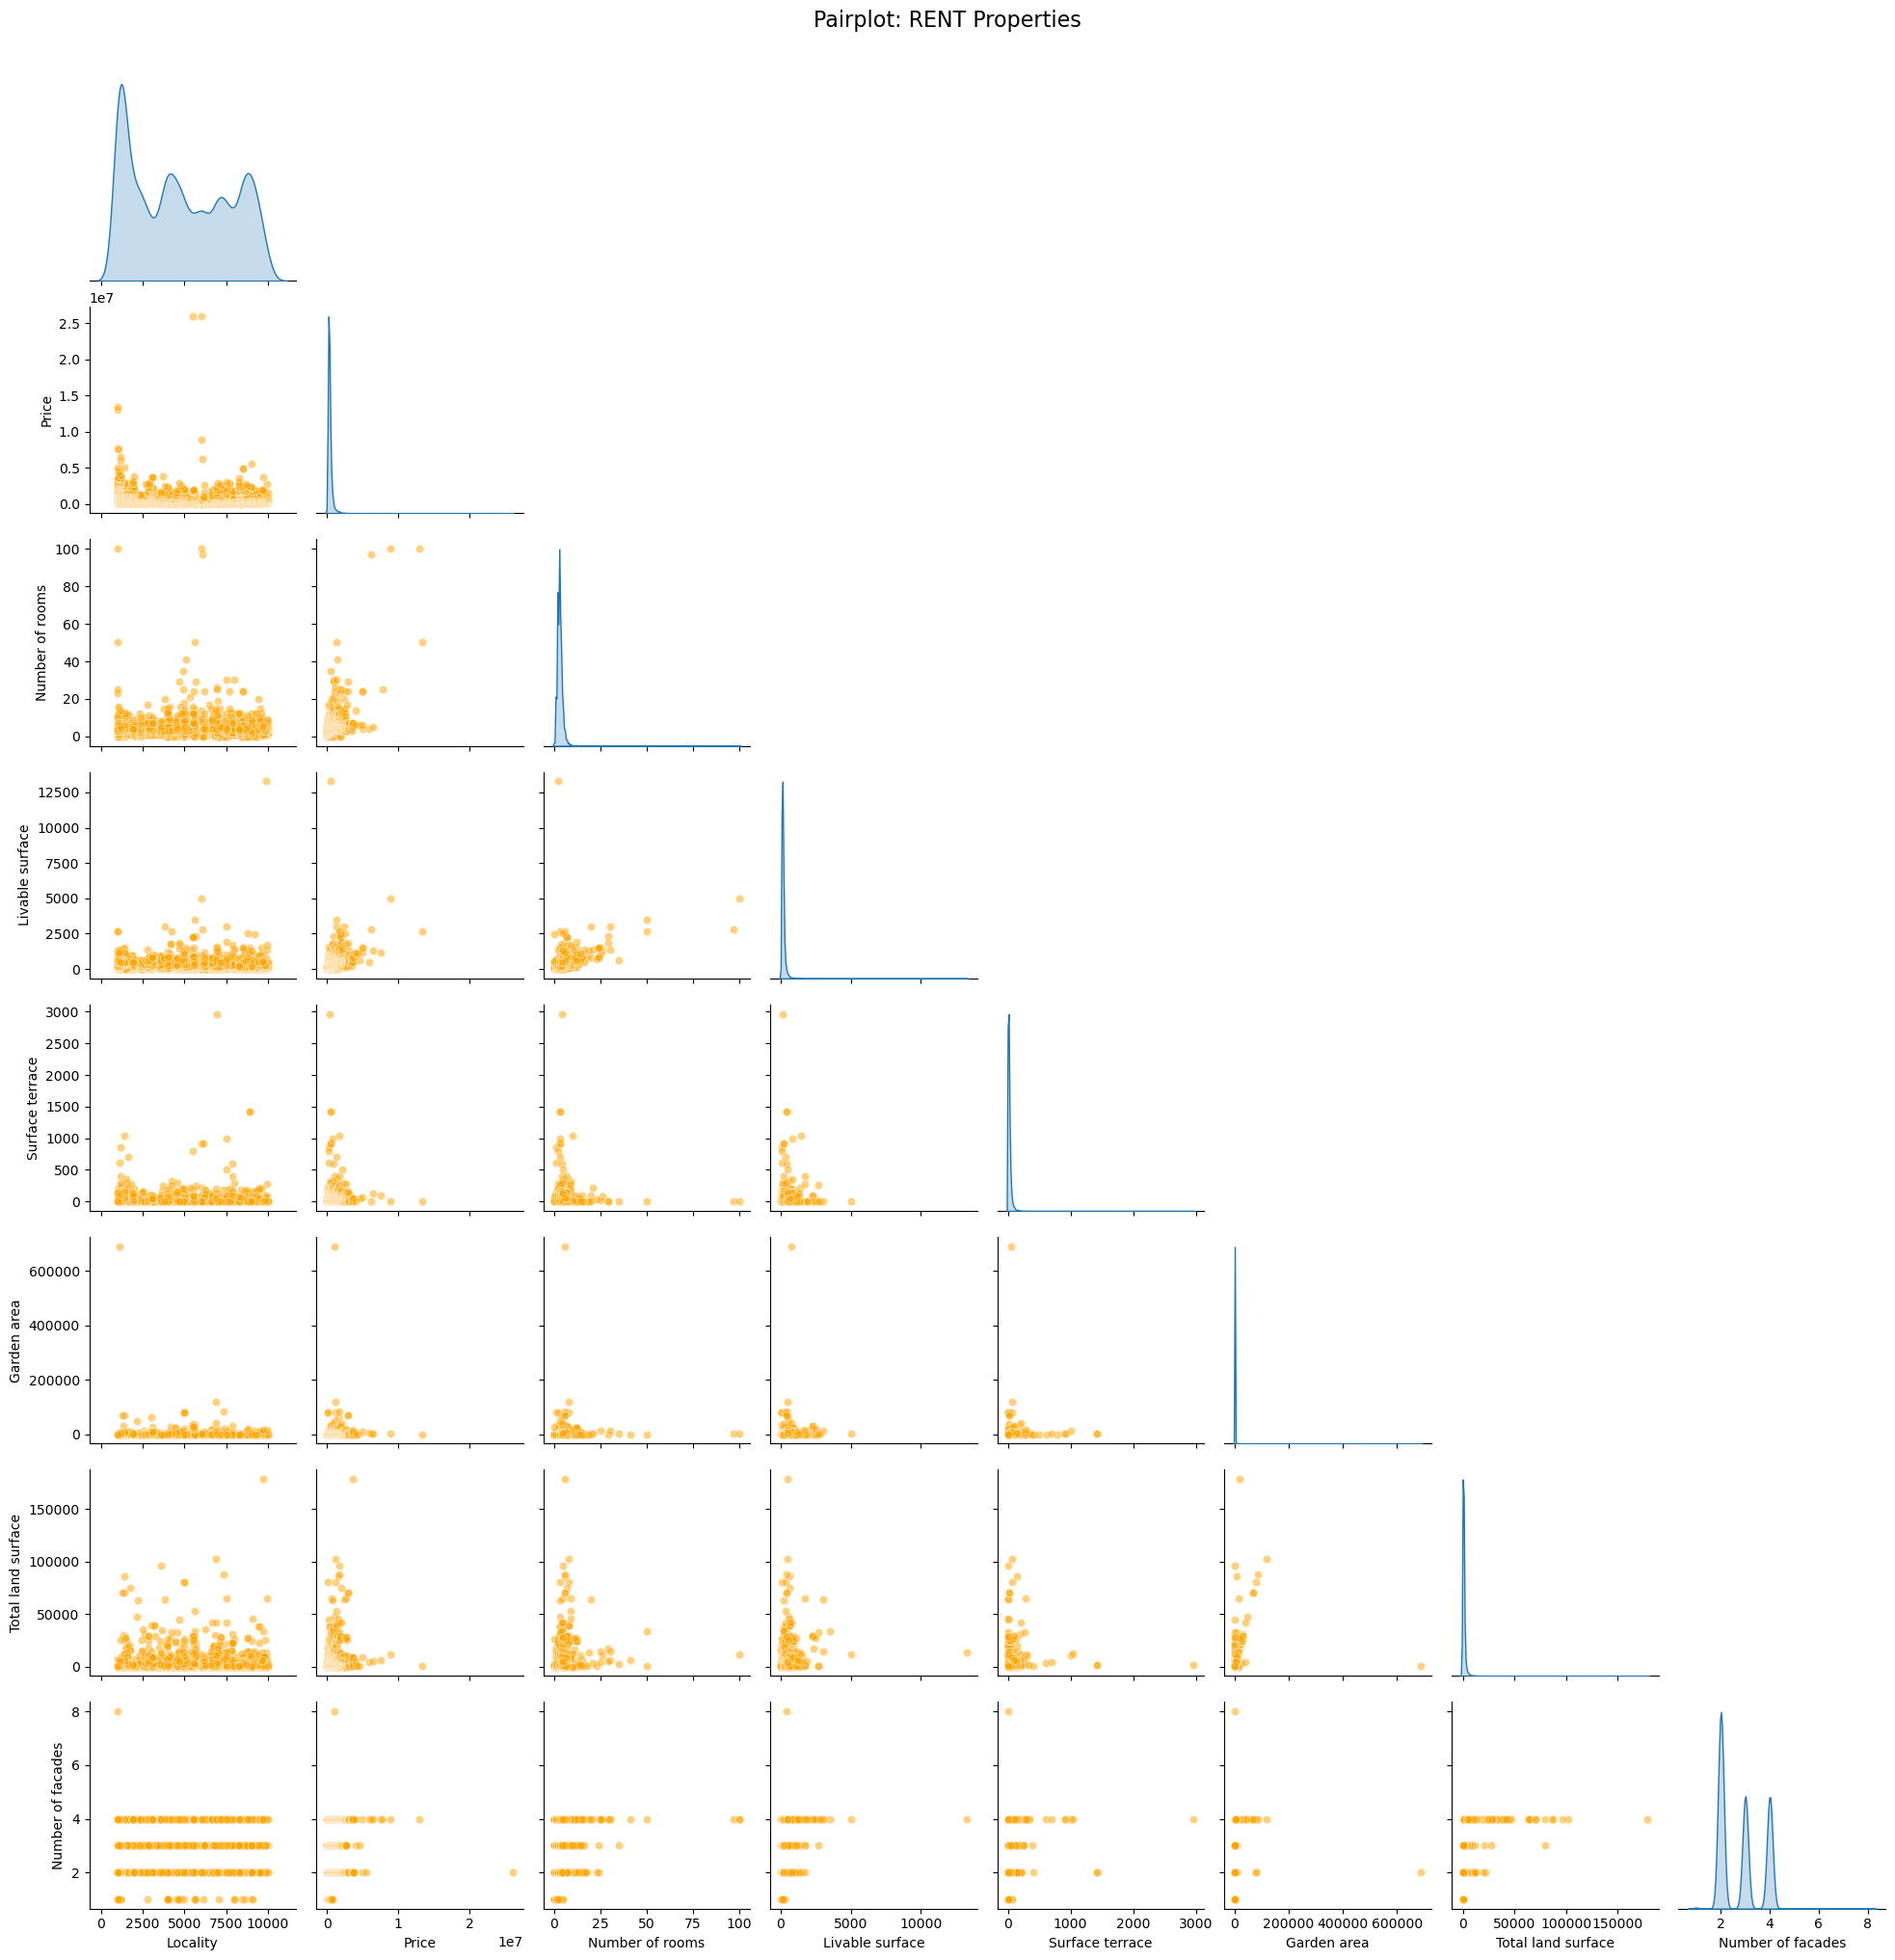

In [12]:
# the numeric columns you want to visualize
num_cols = ['Locality','Price', 'Number of rooms', 'Livable surface','Surface terrace', 'Garden area', 'Total land surface', 'Number of facades']

# --- PLOT 1: SALE ---
print("Generating Pairplot for SALE...")
sale_df = df[df['Type of sale'] == 1][num_cols]
sns.pairplot(sale_df, corner=True, diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Pairplot: SALE Properties', y=1.02, fontsize=16)
import os

# Ensure the output folder exists
output_folder = 'my_graphs'
os.makedirs(output_folder, exist_ok=True)

# Save inside that folder
plt.savefig(os.path.join(output_folder, 'price_per_m2.png'), dpi=300, bbox_inches='tight')
plt.show()

# --- PLOT 2: RENT ---
print("Generating Pairplot for RENT...")
rent_df = df[df['Type of sale'] == 2][num_cols]
sns.pairplot(rent_df, corner=True, diag_kind='kde', plot_kws={'color':'orange', 'alpha':0.5})
plt.suptitle('Pairplot: RENT Properties', y=1.02, fontsize=16)
# Ensure the output folder exists
output_folder = 'my_graphs'
os.makedirs(output_folder, exist_ok=True)

# Save inside that folder
plt.savefig(os.path.join(output_folder, 'price_per_m21.png'), dpi=300, bbox_inches='tight')
plt.show()

In [19]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# 1. Your property data (already loaded)
# -------------------------------------------------------------------
# df = pd.read_csv("your_properties.csv")
print("Property data columns:", df.columns.tolist())

# -------------------------------------------------------------------
# 2. Filter selling properties and compute price per m²
# -------------------------------------------------------------------
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Livable surface'] = pd.to_numeric(df['Livable surface'], errors='coerce')   # adjust column name if needed

df_sale = df[df['Type of sale'] == 2].copy()
df_sale['price_per_m2'] = df_sale['Price'] / df_sale['Livable surface'].replace(0, pd.NA)
df_sale = df_sale.dropna(subset=['price_per_m2'])
df_sale = df_sale[df_sale['price_per_m2'] > 0]   # optional

# -------------------------------------------------------------------
# 3. Load the official postal code → municipality lookup (local Excel file)
# -------------------------------------------------------------------
lookup_file = "Postal codes_2023.xlsx"   # <-- change to your actual filename
print(f"\nLoading postal code lookup from {lookup_file}...")
lookup = pd.read_excel(lookup_file, dtype={'Postcode': str})

# Keep only necessary columns
lookup = lookup[['Postcode', 'Municipality_French', 'Municipality_Dutch']].copy()
lookup.rename(columns={
    'Postcode': 'postcode',
    'Municipality_French': 'municipality_fr',
    'Municipality_Dutch': 'municipality_nl'
}, inplace=True)

lookup = lookup.drop_duplicates(subset=['postcode'])
lookup['postcode'] = lookup['postcode'].astype(str).str.strip()

# -------------------------------------------------------------------
# 4. Merge property data with lookup
# -------------------------------------------------------------------
df_sale['Locality'] = df_sale['Locality'].astype(str).str.strip()
df_with_muni = df_sale.merge(lookup, left_on='Locality', right_on='postcode', how='left')

unmatched = df_with_muni[df_with_muni['municipality_fr'].isna()]
if not unmatched.empty:
    print(f"\nWarning: {len(unmatched)} properties have postal codes not found in official list.")
    print("Examples:", unmatched['Locality'].head().tolist())

df_with_muni = df_with_muni.dropna(subset=['municipality_fr', 'municipality_nl'], how='all')

# -------------------------------------------------------------------
# 5. Aggregate average price per m² by municipality
# -------------------------------------------------------------------
property_by_muni = df_with_muni.groupby(['municipality_fr', 'municipality_nl'])['price_per_m2'].mean().reset_index()

# -------------------------------------------------------------------
# 6. Load the map and prepare names
# -------------------------------------------------------------------
belgium_map = gpd.read_file("communesgemeente-belgium.geojson")

def extract_string(val):
    if isinstance(val, list):
        return val[0] if len(val) > 0 else ''
    return val if pd.notna(val) else ''

for col in ['mun_name_fr', 'mun_name_nl', 'mun_name_de']:
    belgium_map[col + '_str'] = belgium_map[col].apply(extract_string)

belgium_map['fr_clean'] = belgium_map['mun_name_fr_str'].str.strip().str.lower()
belgium_map['nl_clean'] = belgium_map['mun_name_nl_str'].str.strip().str.lower()

property_by_muni['fr_clean'] = property_by_muni['municipality_fr'].str.strip().str.lower()
property_by_muni['nl_clean'] = property_by_muni['municipality_nl'].str.strip().str.lower()

# -------------------------------------------------------------------
# 7. Merge (French first, then Dutch)
# -------------------------------------------------------------------
merged_fr = belgium_map.merge(property_by_muni[['fr_clean', 'price_per_m2']],
                              left_on='fr_clean', right_on='fr_clean', how='left')
merged_nl = belgium_map.merge(property_by_muni[['nl_clean', 'price_per_m2']],
                              left_on='nl_clean', right_on='nl_clean', how='left')

merged = merged_fr.copy()
missing = merged['price_per_m2'].isna()
merged.loc[missing, 'price_per_m2'] = merged_nl.loc[missing, 'price_per_m2']

matched_count = merged['price_per_m2'].notna().sum()
print(f"\nData matched for {matched_count} out of {len(merged)} municipalities.")

# -------------------------------------------------------------------
# 8. Plot
# -------------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
merged.plot(column='price_per_m2', ax=ax, legend=True,
            legend_kwds={'label': "Average price per m² (€)", 'shrink': 0.5},
            cmap='OrRd', missing_kwds={'color': 'lightgrey', 'label': 'No data'},
            edgecolor='white', linewidth=0.1)
ax.set_title("Average Price per m² for Selling Properties\nby Belgian Municipality", fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

Property data columns: ['Link', 'Locality', 'Type of property', 'Subtype of property', 'Price', 'Type of sale', 'Number of rooms', 'Livable surface', 'Fully equipped kitchen', 'Furnished', 'Fireplace', 'Terrace', 'Surface terrace', 'Garden', 'Garden area', 'Total land surface', 'Number of facades', 'Swimming pool', 'State of the property', 'Specific primary energy consumption', 'Garage', 'Date_scraped', 'price_per_m2', 'transaction_type']

Loading postal code lookup from Postal codes_2023.xlsx...


FileNotFoundError: [Errno 2] No such file or directory: 'Postal codes_2023.xlsx'